In [1]:
import numpy as np
import torch
import torch.nn as nn
import sys

In [2]:
sys.path.append('../data_exploration')
from wikidata_dataset_class import GlobalTemporalTextKGDataset

# dummy args — not used since the dataset is already processed on disk
dataset = GlobalTemporalTextKGDataset(
    start_year=0,
    end_year=1800,
    monthly=False,
    json_filename="",
    dataset_filename="limited_monthly_1950_2000_v1.pt",
    root="../data/custom_wikidata/wikidata",
    entity_to_id={},
    relation_to_id={},
    entity_to_data={},
    embed_fn=lambda x: None
)
print(f"dataset len: {len(dataset)}")
print(f"x_global:    {dataset.x_global.shape}")
print(f"num_rels:    {len(dataset.id_to_rel)}")


C:\Users\jaden\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


dataset len: 600
x_global:    torch.Size([110065, 768])
num_rels:    22


In [3]:
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax


class MultiHeadTemporalGAT(MessagePassing):
    def __init__(self, node_dim, edge_emb_dim, num_edge_types, heads=4, dropout=0.1):
        super().__init__(aggr="add")

        # make sure sizing is right
        assert node_dim % heads == 0, "node_dim must be divisible by heads"

        # attributes
        # NOTE: named out_dim to avoid stomping MessagePassing.node_dim
        self.out_dim = node_dim
        self.heads = heads
        self.head_dim = node_dim // heads
        self.dropout = dropout

        # edge embeddings
        self.edge_embedding = nn.Embedding(num_edge_types, edge_emb_dim)

        # projections
        self.W_h = nn.Linear(node_dim, node_dim, bias=False) # for node embeddings in message
        self.W_r = nn.Linear(edge_emb_dim, node_dim, bias=False) # for edge embeddings in message
        self.W_n = nn.Linear(node_dim, node_dim, bias=False) # for node embeddings in attention

        # attention MLP operates per head
        # shared accross all heads (not as good as full multihead, but much cheaper)
        # expects concat of both node embeddings and the edge embedding
        # outputs a scalar, the attention score
        self.att_mlp = nn.Sequential(
            nn.Linear(2 * self.head_dim + edge_emb_dim, self.head_dim),
            nn.LeakyReLU(),
            nn.Linear(self.head_dim, 1)
        )

        # output and normalization
        self.out_proj = nn.Linear(node_dim, node_dim)
        self.norm = nn.LayerNorm(node_dim)

    def forward(self, x, edge_index, edge_type):
        # dims
        # x is (num_nodes, node_dim)
        # edge_index is (2, num_edges)
        # edge_type is (num_edges)

        # get edge embeddings (num_edges, edge_emb_dim)
        edge_attr = self.edge_embedding(edge_type)

        # propagates messages
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        # serves to mix info from different heads
        out = self.out_proj(out)

        # residual and norm
        return self.norm(x + out)

    # message is called in propagate
    def message(self, x_i, x_j, edge_attr, index):
        # apply transfomation to node embeddings
        z_i = self.W_n(x_i) # (num_edges, node_dim)
        z_j = self.W_n(x_j)

        # apply message transfomation to node embedding
        m_j = self.W_h(x_j) # (num_edges, node_dim)

        # apply message transformation to edge embedding and project to node space
        e_j = self.W_r(edge_attr) # (num_edges, node_dim)

        # reshape (num_edges, heads, head_dim) for multihead attention
        z_i = z_i.view(-1, self.heads, self.head_dim)
        z_j = z_j.view(-1, self.heads, self.head_dim)
        m_j = m_j.view(-1, self.heads, self.head_dim)
        e_j = e_j.view(-1, self.heads, self.head_dim)

        # expand edge_attr to heads (num_edges, num_heads, edge_emb_dim)
        # for attention
        edge_attr = edge_attr.unsqueeze(1).repeat(1, self.heads, 1)

        # attention per head
        att_input = torch.cat([z_i, z_j, edge_attr], dim=-1) # (num_edges, num_heads, (2 * head_dim + edge_emb_dim))
        e_ij = self.att_mlp(att_input).squeeze(-1)   # (num_edges, heads)

        # apply softmax to attention scores to get attention weights
        alpha = softmax(e_ij, index)                 # normalize per node
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)

        # calculate messages
        msg = m_j + e_j     # (num_edges, num_heads, head_dim)

        # weight messages and return
        return alpha.unsqueeze(-1) * msg   # (num_edges, heads, head_dim)

    def aggregate(self, inputs, index, ptr=None, dim_size=None):
        # inputs: (num_edges, heads, head_dim) -> flatten heads before scatter
        # use self.out_dim instead of -1 to handle the zero-edge case safely
        inputs_flat = inputs.view(inputs.size(0), self.out_dim)   # (num_edges, out_dim)
        return super().aggregate(inputs_flat, index, ptr, dim_size)  # (num_nodes, out_dim)


In [4]:
class NodeLSTM(nn.Module):
    """
    Per-node temporal memory module.

    Input:
        x_t: current node representations at time t
             shape [num_nodes, input_dim]

        state: optional tuple (h_prev, c_prev)
             h_prev: [num_nodes, hidden_dim]
             c_prev: [num_nodes, hidden_dim]

    Output:
        h_t: updated node hidden states
             shape [num_nodes, hidden_dim]

        (h_t, c_t): updated recurrent state
    """

    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.cell = nn.LSTMCell(input_dim, hidden_dim)

    def init_state(self, num_nodes, device):
        h0 = torch.zeros(num_nodes, self.hidden_dim, device=device)
        c0 = torch.zeros(num_nodes, self.hidden_dim, device=device)
        return h0, c0

    def forward(self, x_t, state=None):
        """
        x_t: [num_nodes, input_dim]
        state: (h_prev, c_prev) or None
        """
        num_nodes = x_t.size(0)
        device = x_t.device

        if state is None:
            h_prev, c_prev = self.init_state(num_nodes, device)
        else:
            h_prev, c_prev = state

        # LSTMCell treats num_nodes like the batch dimension,
        # so each node gets its own temporal update.
        h_t, c_t = self.cell(x_t, (h_prev, c_prev))

        return h_t, (h_t, c_t)

In [ ]:
from collections import defaultdict
import itertools
import random


class TripleProposalStrategy:
    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        raise NotImplementedError


class CurrentEdgeSetStrategy(TripleProposalStrategy):
    """Passes every edge in the current graph as a candidate."""

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        src = edge_index[0].tolist()
        dst = edge_index[1].tolist()
        rel = edge_type.tolist()
        return list(zip(src, rel, dst))


class AllTripletStrategy(TripleProposalStrategy):
    def __init__(self, allowed_relations):
        self.allowed_relations = allowed_relations

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        active = edge_index.unique().tolist()
        proposals = [
            (u, r, v)
            for u, v in itertools.permutations(active, 2)
            for r in self.allowed_relations
        ]
        return proposals


class TwoHopExpansionStrategy(TripleProposalStrategy):
    def __init__(self, allowed_relations, max_per_node=20, max_total_proposals=None):
        self.allowed_relations = allowed_relations
        self.max_per_node = max_per_node
        self.max_total_proposals = max_total_proposals

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        num_nodes = graph_node_states.size(0)

        out_neighbors = defaultdict(set)
        for s, d in zip(edge_index[0].tolist(), edge_index[1].tolist()):
            out_neighbors[s].add(d)

        proposals = []
        total_count = 0

        nodes = list(range(num_nodes))
        random.shuffle(nodes)

        for u in nodes:
            per_node_count = 0
            mids = list(out_neighbors[u])
            random.shuffle(mids)

            for mid in mids:
                vs = list(out_neighbors[mid])
                random.shuffle(vs)

                for v in vs:
                    if u == v:
                        continue

                    rels = list(self.allowed_relations)
                    random.shuffle(rels)

                    for r in rels:
                        proposals.append((u, r, v))
                        total_count += 1

                        if (
                            self.max_total_proposals is not None
                            and total_count >= self.max_total_proposals
                        ):
                            return proposals

                    per_node_count += 1
                    if per_node_count >= self.max_per_node:
                        break

                if per_node_count >= self.max_per_node:
                    break

        return proposals


class SimilarStateStrategy(TripleProposalStrategy):
    def __init__(self, allowed_relations, topk=10, max_total_proposals=None, sample_pool_factor=3):
        self.allowed_relations = allowed_relations
        self.topk = topk
        self.max_total_proposals = max_total_proposals
        self.sample_pool_factor = sample_pool_factor

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        active = edge_index.unique()

        if active.numel() == 0:
            return []

        x = lstm_node_states[active]
        x_norm = x / (x.norm(dim=-1, keepdim=True) + 1e-8)
        sim = x_norm @ x_norm.T

        active_list = active.tolist()
        random.shuffle(active_list)

        node_to_active_idx = {node_id: i for i, node_id in enumerate(active.tolist())}

        proposals = []
        total_count = 0

        for u in active_list:
            i = node_to_active_idx[u]
            pool_k = min(self.topk * self.sample_pool_factor + 1, sim.size(1))
            _, indices = torch.topk(sim[i], k=pool_k)

            candidate_vs = []
            for j in indices.tolist():
                v = active[j].item()
                if u != v:
                    candidate_vs.append(v)

            if len(candidate_vs) > self.topk:
                candidate_vs = random.sample(candidate_vs, self.topk)

            rels = list(self.allowed_relations)
            random.shuffle(rels)

            for v in candidate_vs:
                for r in rels:
                    proposals.append((u, r, v))
                    total_count += 1

                    if (
                        self.max_total_proposals is not None
                        and total_count >= self.max_total_proposals
                    ):
                        return proposals

        return proposals


class TripleProposer(nn.Module):
    def __init__(self, strategies, max_candidates=None, sample_size=None):
        """
        strategies    : list of TripleProposalStrategy; first must be CurrentEdgeSetStrategy
        max_candidates: hard cap on non-current proposals before sampling (safety limit)
        sample_size   : if set, randomly sample exactly this many from current edges
                        AND this many from non-current proposals, giving a balanced
                        50/50 candidate set of size 2 * sample_size
        """
        super().__init__()
        self.strategies = strategies
        self.max_candidates = max_candidates
        self.sample_size = sample_size

    def forward(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        current_set = set(self.strategies[0].propose(
            edge_index=edge_index, edge_type=edge_type,
            graph_node_states=graph_node_states, lstm_node_states=lstm_node_states,
            metadata=metadata,
        ))

        other_set = set()
        for strategy in self.strategies[1:]:
            for p in strategy.propose(
                edge_index=edge_index, edge_type=edge_type,
                graph_node_states=graph_node_states, lstm_node_states=lstm_node_states,
                metadata=metadata,
            ):
                if p not in current_set:
                    other_set.add(p)

        current_list = list(current_set)
        other_list = list(other_set)

        if self.sample_size is not None:
            # sample equally from each side for a balanced candidate set
            if len(current_list) > self.sample_size:
                current_list = random.sample(current_list, self.sample_size)
            if len(other_list) > self.sample_size:
                other_list = random.sample(other_list, self.sample_size)
        elif self.max_candidates is not None:
            other_list = other_list[:self.max_candidates]

        all_proposals = current_list + other_list
        num_current = len(current_list)

        if len(all_proposals) == 0:
            return torch.empty((0, 3), dtype=torch.long, device=graph_node_states.device), 0

        return (
            torch.tensor(all_proposals, dtype=torch.long, device=graph_node_states.device),
            num_current,
        )

In [6]:
class TripleScorer(nn.Module):
    """
    Scores proposed triples (src, rel, dst), conditioned on both:
      1. current node representation from the graph encoder
      2. per-node LSTM hidden state

    Inputs
    ------
    graph_node_states : Tensor [num_nodes, graph_dim]
        Structural node representations from the GNN / graph transformer.
    lstm_node_states : Tensor [num_nodes, lstm_dim]
        Per-node LSTM hidden states.
    proposed_triples : LongTensor [num_triples, 3]
        Each row is (src_node_id, rel_id, dst_node_id)

    Output
    ------
    logits : Tensor [num_triples]
        Raw scores for each proposed triple.
        Use BCEWithLogitsLoss on these logits outside the class.
    """

    def __init__(self, graph_dim, lstm_dim, num_relations, hidden_dim, rel_dim):
        super().__init__()

        self.graph_dim = graph_dim
        self.lstm_dim = lstm_dim
        self.node_dim = graph_dim + lstm_dim
        self.rel_dim = rel_dim if rel_dim is not None else self.node_dim

        self.rel_emb = nn.Embedding(num_relations, self.rel_dim)

        # Small MLP scorer over:
        # [src_graph, src_lstm, rel, dst_graph, dst_lstm]
        self.mlp = nn.Sequential(
            nn.Linear(self.node_dim + self.rel_dim + self.node_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, graph_node_states, lstm_node_states, proposed_triples):
        if proposed_triples.dtype != torch.long:
            proposed_triples = proposed_triples.long()

        src = proposed_triples[:, 0]   # [num_triples]
        rel = proposed_triples[:, 1]   # [num_triples]
        dst = proposed_triples[:, 2]   # [num_triples]

        # Gather graph-conditioned node states
        src_graph = graph_node_states[src]   # [num_triples, graph_dim]
        dst_graph = graph_node_states[dst]   # [num_triples, graph_dim]

        # Gather temporal LSTM node states
        src_lstm = lstm_node_states[src]     # [num_triples, lstm_dim]
        dst_lstm = lstm_node_states[dst]     # [num_triples, lstm_dim]

        # Combine graph + temporal information per endpoint
        src_state = torch.cat([src_graph, src_lstm], dim=-1)   # [num_triples, node_dim]
        dst_state = torch.cat([dst_graph, dst_lstm], dim=-1)   # [num_triples, node_dim]

        # Relation embedding
        rel_state = self.rel_emb(rel)                         # [num_triples, rel_dim]

        # Final triple representation
        triple_repr = torch.cat([src_state, rel_state, dst_state], dim=-1)

        # Raw logits
        logits = self.mlp(triple_repr).squeeze(-1)            # [num_triples]
        return logits

In [ ]:
def proposed_triple_bce_loss(
    proposed_triples: torch.Tensor,
    logits: torch.Tensor,
    next_edge_index: torch.Tensor,
    next_edge_type: torch.Tensor,
    num_current_triples: int,
    use_weighting: bool = True,
    proposed_weight_scale: float = 3.0,
    extra_positive_proposed_scale: float = 2.0,
    auto_pos_weight: bool = True,
    reduction: str = "mean",
):
    """
    BCE loss for next-graph prediction over a candidate triple set.

    use_weighting : bool
        When True, applies auto_pos_weight and proposal-region upweighting to
        compensate for class and region imbalance.
        When False, plain unweighted BCE — use this when the candidate set is
        already balanced (equal current and non-current proposals).
    """
    device = proposed_triples.device
    num_candidates = proposed_triples.size(0)

    if proposed_triples.ndim != 2 or proposed_triples.size(1) != 3:
        raise ValueError("proposed_triples must have shape [num_candidates, 3]")
    if logits.ndim != 1 or logits.size(0) != num_candidates:
        raise ValueError("logits must have shape [num_candidates]")
    if next_edge_index.ndim != 2 or next_edge_index.size(0) != 2:
        raise ValueError("next_edge_index must have shape [2, num_true_next_edges]")
    if next_edge_type.ndim != 1 or next_edge_type.size(0) != next_edge_index.size(1):
        raise ValueError("next_edge_type must have shape [num_true_next_edges]")
    if not (0 <= num_current_triples <= num_candidates):
        raise ValueError("num_current_triples must be in [0, num_candidates]")

    # Build ground-truth label for each candidate
    next_src = next_edge_index[0]
    next_dst = next_edge_index[1]
    next_rel = next_edge_type
    true_next_set = set(map(tuple, torch.stack([next_src, next_rel, next_dst], dim=1).long().tolist()))

    labels_list = [
        1.0 if tuple(triple) in true_next_set else 0.0
        for triple in proposed_triples.tolist()
    ]
    labels = torch.tensor(labels_list, dtype=logits.dtype, device=device)
    positives_mask = labels.bool()

    if not use_weighting:
        # plain BCE, no reweighting
        loss = F.binary_cross_entropy_with_logits(logits, labels, reduction=reduction)
        final_weights = torch.ones_like(labels)
        return loss, labels, positives_mask, final_weights

    # ----- class imbalance weighting -----
    pos_weight = None
    if auto_pos_weight:
        num_pos = labels.sum()
        num_neg = labels.numel() - num_pos
        if num_pos.item() > 0:
            pos_weight = (num_neg / num_pos).to(device=device, dtype=logits.dtype)

    loss_per_example = F.binary_cross_entropy_with_logits(
        logits, labels, pos_weight=pos_weight, reduction="none",
    )

    # ----- proposal-region weighting -----
    final_weights = torch.ones_like(labels, dtype=logits.dtype, device=device)

    if num_current_triples < num_candidates:
        proposal_mask = torch.zeros(num_candidates, dtype=torch.bool, device=device)
        proposal_mask[num_current_triples:] = True
        final_weights[proposal_mask] *= proposed_weight_scale
        positive_proposal_mask = proposal_mask & positives_mask
        final_weights[positive_proposal_mask] *= extra_positive_proposed_scale

    weighted_loss = loss_per_example * final_weights

    if reduction == "mean":
        loss = weighted_loss.mean()
    elif reduction == "sum":
        loss = weighted_loss.sum()
    elif reduction == "none":
        loss = weighted_loss
    else:
        raise ValueError("reduction must be 'mean', 'sum', or 'none'")

    return loss, labels, positives_mask, final_weights

In [ ]:
import os
import networkx as nx
import matplotlib.pyplot as plt
import time

class Temporal_GNN(nn.Module):
    def __init__(
        self,
        in_dim,
        hidden_dim,
        edge_emb_dim,
        num_edge_types,
        num_gnn_layers=2,
        heads=4,
        dropout=0.1,
        max_candidates=None,
        sample_size=None,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_edge_types = num_edge_types

        self.init_embedding = nn.Linear(in_dim, hidden_dim)

        self.gnn_layers = nn.ModuleList([
            MultiHeadTemporalGAT(hidden_dim, edge_emb_dim, num_edge_types, heads=heads, dropout=dropout)
            for _ in range(num_gnn_layers)
        ])

        self.node_lstm = NodeLSTM(hidden_dim, hidden_dim)

        all_rels = list(range(num_edge_types))

        # each non-current strategy is capped at max_candidates so they generate
        # enough to fill sample_size but don't run away on large graphs
        strategy_cap = max_candidates

        self.proposer = TripleProposer(
            strategies=[
                CurrentEdgeSetStrategy(),
                TwoHopExpansionStrategy(
                    allowed_relations=all_rels,
                    max_per_node=10,
                    max_total_proposals=strategy_cap,
                ),
                SimilarStateStrategy(
                    allowed_relations=all_rels,
                    topk=5,
                    max_total_proposals=strategy_cap,
                    sample_pool_factor=3,
                ),
            ],
            max_candidates=max_candidates,
            sample_size=sample_size,
        )

        self.scorer = TripleScorer(
            graph_dim=hidden_dim,
            lstm_dim=hidden_dim,
            num_relations=num_edge_types,
            hidden_dim=hidden_dim,
            rel_dim=edge_emb_dim,
        )

    def forward(self, x_global, edge_index, edge_type, lstm_state=None):
        x = self.init_embedding(x_global)

        for gnn in self.gnn_layers:
            x = gnn(x, edge_index, edge_type)

        graph_node_states = x

        lstm_h, lstm_state = self.node_lstm(graph_node_states, lstm_state)

        proposed_triples, num_current_triples = self.proposer(
            edge_index=edge_index,
            edge_type=edge_type,
            graph_node_states=graph_node_states,
            lstm_node_states=lstm_h,
        )

        logits = self.scorer(graph_node_states, lstm_h, proposed_triples)

        return logits, proposed_triples, num_current_triples, lstm_state

    @torch.no_grad()
    def gen(self, x_global, edge_index, edge_type, id_to_entity, id_to_rel,
            num_steps=5, topk=20, threshold=0.5, device='cpu', save_dir=None):
        self.eval()
        x_global   = x_global.to(device)
        edge_index = edge_index.to(device)
        edge_type  = edge_type.to(device)
        lstm_state = None

        for step in range(num_steps):
            logits, proposed_triples, _, lstm_state = self.forward(
                x_global, edge_index, edge_type, lstm_state
            )

            if proposed_triples.size(0) == 0:
                print(f"step {step + 1}: no candidates proposed, stopping.")
                break

            probs = torch.sigmoid(logits)
            keep = torch.bernoulli(probs).bool()
            selected = proposed_triples[keep]

            if selected.size(0) == 0:
                k = min(topk, probs.size(0))
                weights = probs
                if torch.sum(weights) <= 0:
                    weights = torch.ones_like(weights)
                selected_idx = torch.multinomial(weights, num_samples=k, replacement=False)
                selected = proposed_triples[selected_idx]

            edge_index = torch.stack([selected[:, 0], selected[:, 2]], dim=0)
            edge_type = selected[:, 1]

            G = nx.DiGraph()
            for src_id, rel_id, dst_id in selected.cpu().tolist():
                src_lbl = id_to_entity.get(src_id, str(src_id))
                dst_lbl = id_to_entity.get(dst_id, str(dst_id))
                rel_lbl = id_to_rel.get(rel_id, str(rel_id))
                G.add_edge(src_lbl, dst_lbl, relation=rel_lbl)

            fig, ax = plt.subplots(figsize=(14, 10))
            pos = nx.spring_layout(G, seed=42)
            nx.draw_networkx_nodes(G, pos, node_size=400, ax=ax)
            nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
            nx.draw_networkx_edges(
                G, pos, ax=ax,
                arrows=True, arrowstyle='-|>', arrowsize=20,
                connectionstyle='arc3,rad=0.1',
                min_source_margin=15, min_target_margin=15,
            )
            nx.draw_networkx_edge_labels(
                G, pos,
                edge_labels=nx.get_edge_attributes(G, 'relation'),
                font_size=6, ax=ax,
            )
            ax.set_title(
                f"Generated graph — step {step + 1}  "
                f"({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)"
            )
            ax.axis('off')
            plt.tight_layout()

            if save_dir:
                os.makedirs(save_dir, exist_ok=True)
                out_path = os.path.join(save_dir, f"step_{step + 1:03d}.png")
                plt.savefig(out_path, dpi=100)
                plt.close()
                print(f"step {step + 1}: {G.number_of_nodes()} nodes, "
                      f"{G.number_of_edges()} edges  ->  {out_path}")
            else:
                plt.show()
                print(f"step {step + 1}: {G.number_of_nodes()} nodes, "
                      f"{G.number_of_edges()} edges")

        return edge_index, edge_type

In [ ]:
VAL_STEPS = 10

def train_epoch(model, dataset, optimizer, device, train_end):
    model.train()
    total_loss, steps = 0.0, 0
    x_global   = dataset.x_global.to(device)
    lstm_state = None

    for t in range(train_end - 1):
        data_t    = dataset[t]
        data_next = dataset[t + 1]
        edge_index = data_t.edge_index.to(device)
        edge_type  = data_t.edge_type.to(device)

        logits, proposed_triples, num_current_triples, lstm_state = model(x_global, edge_index, edge_type, lstm_state)
        lstm_state = (lstm_state[0].detach(), lstm_state[1].detach())

        if proposed_triples.size(0) == 0:
            continue

        loss, labels, positives_mask, weights = proposed_triple_bce_loss(
            proposed_triples=proposed_triples,
            logits=logits,
            next_edge_index=data_next.edge_index.to(device),
            next_edge_type=data_next.edge_type.to(device),
            num_current_triples=num_current_triples,
            use_weighting=False,
            reduction="mean",
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        steps += 1

    return total_loss / max(steps, 1)


@torch.no_grad()
def validate(model, dataset, device, val_start):
    model.eval()
    total_loss    = 0.0
    total_hits1   = 0.0
    total_hits3   = 0.0
    total_hits10  = 0.0
    total_pos     = 0
    total_tp      = 0
    total_fp      = 0
    total_fn      = 0
    total_pos_score = 0.0
    total_neg_score = 0.0
    total_pos_score_count = 0
    total_neg_score_count = 0
    steps         = 0
    x_global      = dataset.x_global.to(device)
    lstm_state    = None

    for t in range(max(0, val_start - 5), val_start):
        data_t = dataset[t]
        _, _, _, lstm_state = model(
            x_global,
            data_t.edge_index.to(device),
            data_t.edge_type.to(device),
            lstm_state,
        )
        lstm_state = (lstm_state[0].detach(), lstm_state[1].detach())

    for t in range(val_start, len(dataset) - 1):
        data_t    = dataset[t]
        data_next = dataset[t + 1]
        edge_index = data_t.edge_index.to(device)
        edge_type  = data_t.edge_type.to(device)

        logits, proposed_triples, _, lstm_state = model(x_global, edge_index, edge_type, lstm_state)
        lstm_state = (lstm_state[0].detach(), lstm_state[1].detach())

        if proposed_triples.size(0) == 0:
            continue

        loss, labels, pos_mask, _ = proposed_triple_bce_loss(
            proposed_triples=proposed_triples,
            logits=logits,
            next_edge_index=data_next.edge_index.to(device),
            next_edge_type=data_next.edge_type.to(device),
            num_current_triples=proposed_triples.size(0),
            use_weighting=False,
            reduction="mean",
        )
        total_loss += loss.item()

        num_pos = pos_mask.sum().item()
        if num_pos > 0:
            pos_scores = logits[pos_mask]
            ranks = (logits.unsqueeze(0) > pos_scores.unsqueeze(1)).sum(dim=1) + 1
            total_hits1  += (ranks <= 1).float().sum().item()
            total_hits3  += (ranks <= 3).float().sum().item()
            total_hits10 += (ranks <= 10).float().sum().item()
            total_pos    += num_pos

        pred_mask = logits > 0
        neg_mask  = ~pos_mask
        total_tp += (pred_mask & pos_mask).sum().item()
        total_fp += (pred_mask & neg_mask).sum().item()
        total_fn += (~pred_mask & pos_mask).sum().item()

        if pos_mask.sum() > 0:
            total_pos_score       += logits[pos_mask].sum().item()
            total_pos_score_count += pos_mask.sum().item()
        if neg_mask.sum() > 0:
            total_neg_score       += logits[neg_mask].sum().item()
            total_neg_score_count += neg_mask.sum().item()

        steps += 1

    n         = max(total_pos, 1)
    precision = total_tp / max(total_tp + total_fp, 1)
    recall    = total_tp / max(total_tp + total_fn, 1)
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    mean_pos_score = total_pos_score / max(total_pos_score_count, 1)
    mean_neg_score = total_neg_score / max(total_neg_score_count, 1)

    return {
        "loss":           total_loss / max(steps, 1),
        "hits@1":         total_hits1  / n,
        "hits@3":         total_hits3  / n,
        "hits@10":        total_hits10 / n,
        "precision":      precision,
        "recall":         recall,
        "f1":             f1,
        "score_gap":      mean_pos_score - mean_neg_score,
        "mean_pos_score": mean_pos_score,
        "mean_neg_score": mean_neg_score,
    }


# ---- hyperparams ----
HIDDEN_DIM     = 256
EDGE_EMB_DIM   = 64
NUM_GNN_LAYERS = 2
HEADS          = 4
DROPOUT        = 0.1
LR             = 1e-3
EPOCHS         = 50
MAX_CANDS      = 500   # per-strategy generation cap (safety limit)
SAMPLE_SIZE    = 1000  # sample this many from current edges + this many from proposals

device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IN_DIM         = dataset.x_global.shape[1]
NUM_EDGE_TYPES = len(dataset.id_to_rel)
TRAIN_END      = len(dataset) - VAL_STEPS
print(f"device: {device}  IN_DIM: {IN_DIM}  NUM_EDGE_TYPES: {NUM_EDGE_TYPES}")
print(f"train timesteps: 0–{TRAIN_END - 1}  |  val timesteps: {TRAIN_END}–{len(dataset) - 1}")

model = Temporal_GNN(
    in_dim=IN_DIM,
    hidden_dim=HIDDEN_DIM,
    edge_emb_dim=EDGE_EMB_DIM,
    num_edge_types=NUM_EDGE_TYPES,
    num_gnn_layers=NUM_GNN_LAYERS,
    heads=HEADS,
    dropout=DROPOUT,
    max_candidates=MAX_CANDS,
    sample_size=SAMPLE_SIZE,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, dataset, optimizer, device, train_end=TRAIN_END)
    v = validate(model, dataset, device, val_start=TRAIN_END)
    history.append({"epoch": epoch, "train_loss": train_loss, **v})
    print(
        f"epoch {epoch:3d} | "
        f"train {train_loss:.6f} | "
        f"val {v['loss']:.6f} | "
        f"P {v['precision']:.6f}  R {v['recall']:.6f}  F1 {v['f1']:.6f} | "
        f"gap {v['score_gap']:.6f} (pos {v['mean_pos_score']:.6f} neg {v['mean_neg_score']:.6f}) | "
        f"h@1 {v['hits@1']:.6f}  h@3 {v['hits@3']:.6f}  h@10 {v['hits@10']:.6f}"
    )

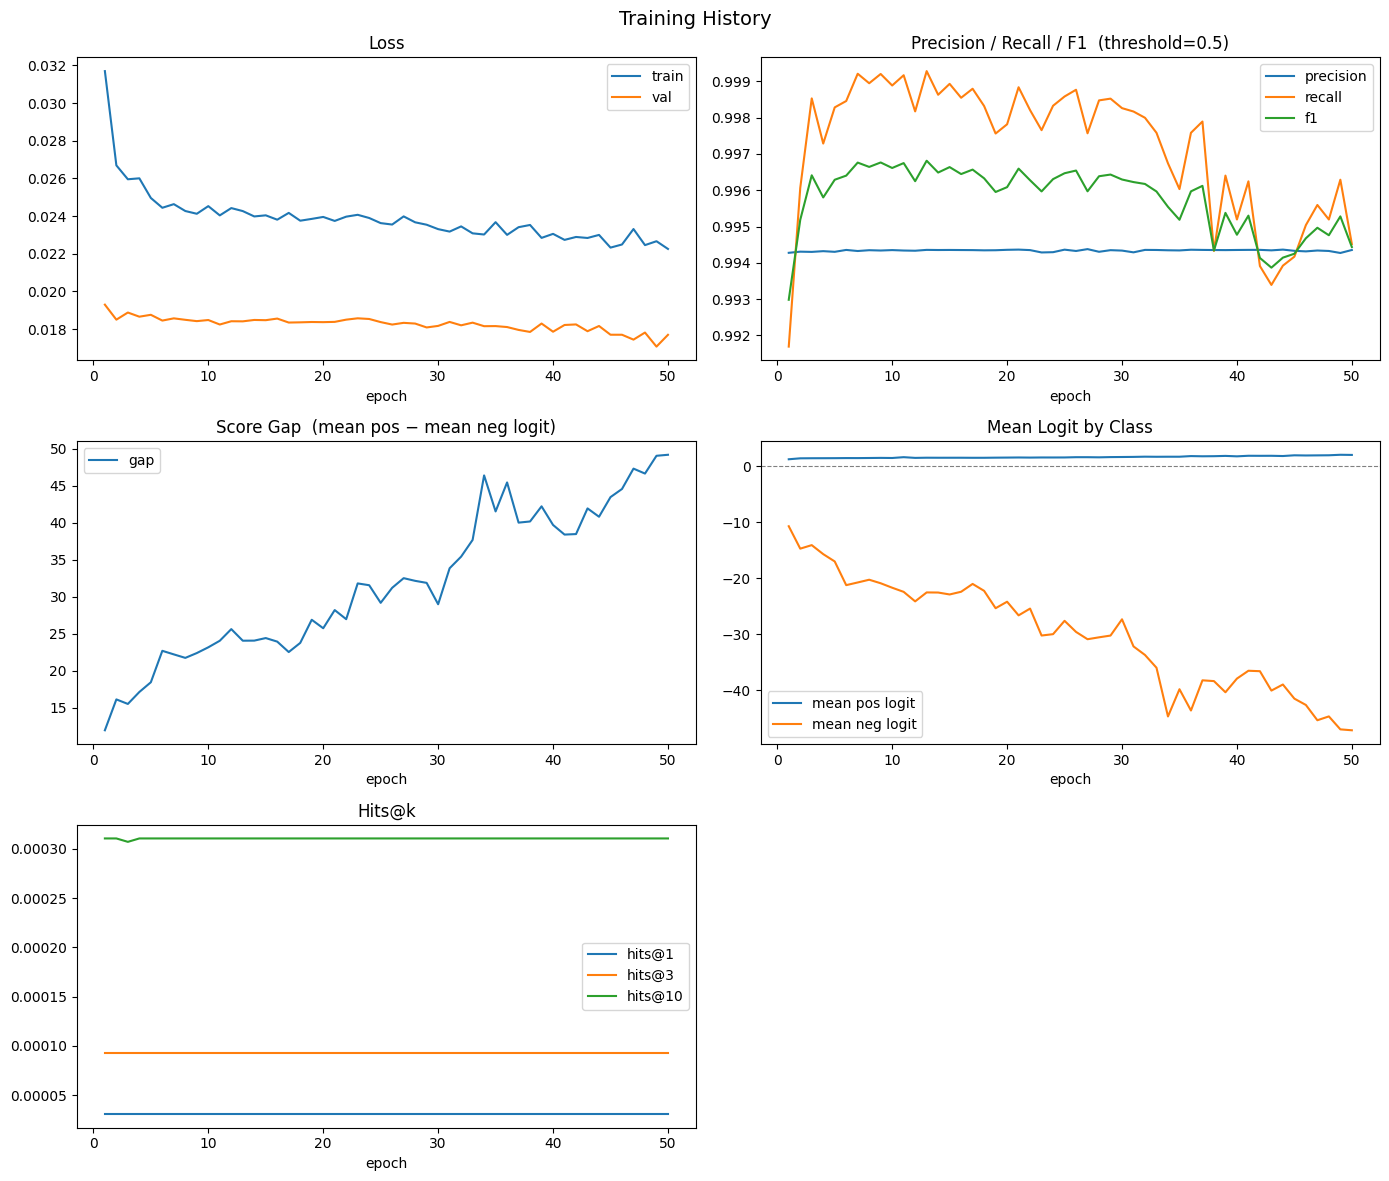

In [ ]:
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Training History", fontsize=14)

# loss
ax = axes[0, 0]
ax.plot(epochs, [h["train_loss"] for h in history], label="train")
ax.plot(epochs, [h["loss"] for h in history], label="val")
ax.set_title("Loss")
ax.set_xlabel("epoch")
ax.legend()

# precision / recall / f1
ax = axes[0, 1]
ax.plot(epochs, [h["precision"] for h in history], label="precision")
ax.plot(epochs, [h["recall"] for h in history], label="recall")
ax.plot(epochs, [h["f1"] for h in history], label="f1")
ax.set_title("Precision / Recall / F1  (threshold=0.5)")
ax.set_xlabel("epoch")
ax.legend()

# score gap
ax = axes[1, 0]
ax.plot(epochs, [h["score_gap"] for h in history], label="gap")
ax.set_title("Score Gap  (mean pos − mean neg logit)")
ax.set_xlabel("epoch")
ax.legend()

# mean pos / neg scores
ax = axes[1, 1]
ax.plot(epochs, [h["mean_pos_score"] for h in history], label="mean pos logit")
ax.plot(epochs, [h["mean_neg_score"] for h in history], label="mean neg logit")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Mean Logit by Class")
ax.set_xlabel("epoch")
ax.legend()

# hits@k
ax = axes[2, 0]
ax.plot(epochs, [h["hits@1"]  for h in history], label="hits@1")
ax.plot(epochs, [h["hits@3"]  for h in history], label="hits@3")
ax.plot(epochs, [h["hits@10"] for h in history], label="hits@10")
ax.set_title("Hits@k")
ax.set_xlabel("epoch")
ax.legend()

# hide unused subplot
axes[2, 1].axis("off")

plt.tight_layout()
plt.show()


In [14]:
torch.save(model, r"models\limited_monthly_1950_2000_50e_v1.pt")

In [ ]:
model = torch.load(r"models\limited_monthly_1950_2000_50e_v1.pt", weights_only=False)
model.eval()
print("loaded")

In [ ]:
from collections import deque

def sample_subgraph(edge_index, edge_type, num_nodes):
    """BFS expansion from the highest-degree node, guaranteeing a connected subgraph."""
    if edge_index.size(1) == 0:
        return edge_index, edge_type

    src_list = edge_index[0].tolist()
    dst_list = edge_index[1].tolist()

    all_nodes, counts = edge_index.flatten().unique(return_counts=True)
    if all_nodes.numel() <= num_nodes:
        return edge_index, edge_type

    # build undirected adjacency for BFS
    neighbors = {}
    for node in all_nodes.tolist():
        neighbors[node] = []
    for s, d in zip(src_list, dst_list):
        neighbors[s].append(d)
        neighbors[d].append(s)

    # start from the highest-degree node
    seed = all_nodes[counts.argmax()].item()
    visited = {seed}
    queue = deque([seed])

    while queue and len(visited) < num_nodes:
        node = queue.popleft()
        for nb in neighbors[node]:
            if nb not in visited:
                visited.add(nb)
                queue.append(nb)
                if len(visited) >= num_nodes:
                    break

    mask = torch.tensor(
        [(s in visited and d in visited) for s, d in zip(src_list, dst_list)],
        dtype=torch.bool,
    )
    return edge_index[:, mask], edge_type[mask]


SUBGRAPH_NODES = 50
start = dataset[100]

sub_edge_index, sub_edge_type = sample_subgraph(
    start.edge_index, start.edge_type, num_nodes=SUBGRAPH_NODES
)
print(f"subgraph: {sub_edge_index.unique().numel()} nodes, {sub_edge_index.size(1)} edges")

# --- display initial subgraph ---
G_init = nx.DiGraph()
for src_id, rel_id, dst_id in zip(sub_edge_index[0].tolist(), sub_edge_type.tolist(), sub_edge_index[1].tolist()):
    src_lbl = dataset.id_to_entity.get(src_id, str(src_id))
    dst_lbl = dataset.id_to_entity.get(dst_id, str(dst_id))
    rel_lbl = dataset.id_to_rel.get(rel_id, str(rel_id))
    G_init.add_edge(src_lbl, dst_lbl, relation=rel_lbl)

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G_init, seed=42)
nx.draw_networkx_nodes(G_init, pos, node_size=400, ax=ax)
nx.draw_networkx_labels(G_init, pos, font_size=7, ax=ax)
nx.draw_networkx_edges(
    G_init, pos, ax=ax,
    arrows=True, arrowstyle='-|>', arrowsize=20,
    connectionstyle='arc3,rad=0.1',
    min_source_margin=15, min_target_margin=15,
)
nx.draw_networkx_edge_labels(
    G_init, pos,
    edge_labels=nx.get_edge_attributes(G_init, 'relation'),
    font_size=6, ax=ax,
)
ax.set_title(
    f"Initial subgraph (t=100) — "
    f"{G_init.number_of_nodes()} nodes, {G_init.number_of_edges()} edges"
)
ax.axis('off')
plt.tight_layout()
plt.show()

model.gen(
    x_global     = dataset.x_global,
    edge_index   = sub_edge_index,
    edge_type    = sub_edge_type,
    id_to_entity = dataset.id_to_entity,
    id_to_rel    = dataset.id_to_rel,
    num_steps    = 5,
    topk         = 25,
    threshold    = 0.5,
    device       = device,
)

In [ ]:
# import os
# from datetime import datetime

# save_dir = "models"
# os.makedirs(save_dir, exist_ok=True)

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# save_path = os.path.join(save_dir, f"temporal_gnn_{timestamp}.pt")

# torch.save(model, save_path)
# print(f"saved full model to {save_path}")